In [3]:
import pandas as pd
import numpy as np
import xgboost as xgb 

# 1. CREATE SYNTHETIC CLIMATE DATA (Simulating 10 years of daily data for one district)
# When you have the real DiCRA CSVs, you will just use: df = pd.read_csv("dicra_data.csv")
np.random.seed(42)
dates = pd.date_range(start="2010-01-01", end="2020-12-31", freq='D')

df = pd.DataFrame({
    'Date': dates,
    'District': 'Khandwa',
    'Tmax': np.random.normal(loc=35, scale=5, size=len(dates)), # Average 35C, varying by 5C
    'Soil_Moisture': np.random.normal(loc=0.3, scale=0.1, size=len(dates)) # 30% moisture average
})

# 2. FEATURE ENGINEERING: Calculate your critical thresholds (The magic of your CSI!)
# We calculate the 95th percentile for heat, and 5th percentile for drought based on history
tmax_95th = df['Tmax'].quantile(0.95)
sm_5th = df['Soil_Moisture'].quantile(0.05)

print(f"Historical 95th Percentile Heat Threshold: {tmax_95th:.1f}°C")
print(f"Historical 5th Percentile Moisture Threshold: {sm_5th:.3f}\n")

# Create flags (1 if threshold broken, 0 if safe)
df['Heat_Anomaly_Flag'] = (df['Tmax'] >= tmax_95th).astype(int)
df['Drought_Anomaly_Flag'] = (df['Soil_Moisture'] <= sm_5th).astype(int)

# 3. ADVANCED ENGINEERING: Compound Stress & Rolling Averages
# Crops don't die in 1 day. Let's calculate a 7-day rolling average of heat
df['Tmax_7Day_Avg'] = df['Tmax'].rolling(window=7).mean()

# The Compound Stress Flag (Did Heat AND Drought happen on the exact same day?)
df['Compound_Stress_Event'] = (df['Heat_Anomaly_Flag'] & df['Drought_Anomaly_Flag'])

# 4. SIMULATING THE TARGET VARIABLE (NDVI / Crop Death)
# If Compound Stress is True, there is a high chance the crop dies (NDVI Drops = 1)
# We add a little random noise because nature isn't perfect
df['Target_Crop_Failure'] = np.where(
    df['Compound_Stress_Event'] == True,
    np.random.choice([1, 0], p=[0.85, 0.15], size=len(df)), # 85% chance of crop failure if stressed
    np.random.choice([1, 0], p=[0.05, 0.95], size=len(df))  # 5% baseline risk of failure normally
)

# Clean up any NaN values created by rolling averages
df = df.dropna()

print("Master DataFrame Ready for XGBoost/LightGBM:")
display(df.tail()) 

Historical 95th Percentile Heat Threshold: 43.4°C
Historical 5th Percentile Moisture Threshold: 0.128

Master DataFrame Ready for XGBoost/LightGBM:


,Date,District,Tmax,Soil_Moisture,Heat_Anomaly_Flag,Drought_Anomaly_Flag,Tmax_7Day_Avg,Compound_Stress_Event,Target_Crop_Failure
4013,2020-12-27,Khandwa,35.993400,0.450195,0,0,33.104231,0,0
4014,2020-12-28,Khandwa,34.604663,0.441136,0,0,33.497672,0,0
4015,2020-12-29,Khandwa,32.104379,0.378535,0,0,33.432779,0,0
4016,2020-12-30,Khandwa,32.595831,0.267339,0,0,32.636950,0,0
4017,2020-12-31,Khandwa,38.480840,0.498538,0,0,33.118048,0,0


Initializing Phase 2: Training XGBoost Model...

Training on 3209 days of data...
Testing on 803 days of future data...

--- MODEL PERFORMANCE METRICS ---
                 precision    recall  f1-score   support

  Crop Safe (0)       0.95      0.79      0.86       764
Crop Failed (1)       0.04      0.15      0.06        39

       accuracy                           0.76       803
      macro avg       0.49      0.47      0.46       803
   weighted avg       0.90      0.76      0.82       803



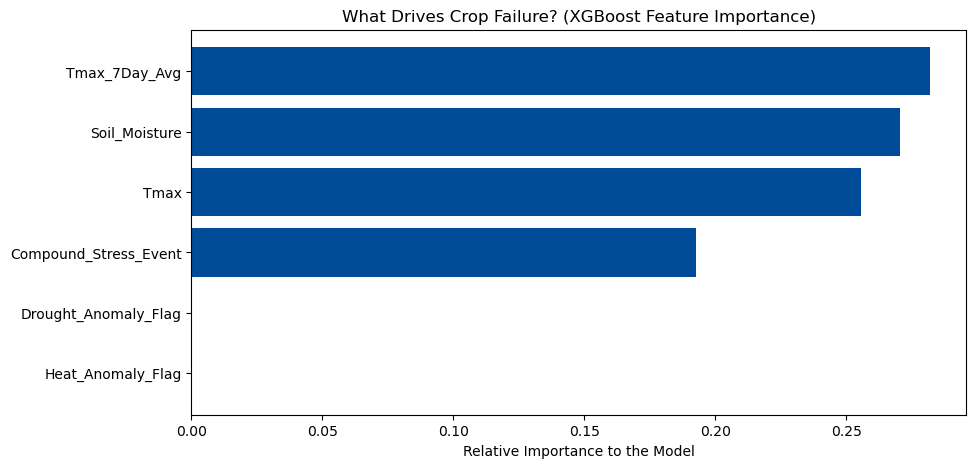

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt # Used for the feature importance graph

print("Initializing Phase 2: Training XGBoost Model...\n")

# 1. PREPARE THE DATA (Separating what we know from what we want to predict)
# We drop 'Date' and 'District' because XGBoost needs pure numbers
features = df.drop(columns=['Date', 'District', 'Target_Crop_Failure'])
target = df['Target_Crop_Failure']

# 2. SPLIT THE DATA (80% for studying/training, 20% for testing/blind exam)
# Note: For time series, we usually don't shuffle, so it tests on the future!
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, shuffle=False
)

print(f"Training on {len(X_train)} days of data...")
print(f"Testing on {len(X_test)} days of future data...\n")

# 3. BUILD AND TRAIN THE XGBOOST MODEL
# scale_pos_weight helps because crop failures are rare events (imbalanced data)
ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)

xgb_model = xgb.XGBClassifier(
    n_estimators=100,         # Use 100 decision trees
    max_depth=4,              # Keep trees shallow to prevent overfitting
    learning_rate=0.1,
    scale_pos_weight=ratio,   # Tell XGBoost to pay extra attention to crop failures!
    random_state=42,
    eval_metric='logloss'
)

# This single line is where the actual "Machine Learning" happens:
xgb_model.fit(X_train, y_train)

# 4. TEST THE MODEL ON THE FUTURE 20% DATA
predictions = xgb_model.predict(X_test)

# 5. EVALUATE THE RESULTS (The Moment of Truth)
print("--- MODEL PERFORMANCE METRICS ---")
print(classification_report(y_test, predictions, target_names=['Crop Safe (0)', 'Crop Failed (1)']))

# 6. FEATURE IMPORTANCE (The "Why")
# This proves to NABARD/Insurers *why* the model triggered a payout.
importance = pd.DataFrame({
    'Feature': features.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=True)

# Plot the graph
plt.figure(figsize=(10, 5))
plt.barh(importance['Feature'], importance['Importance'], color='#004C99')
plt.title("What Drives Crop Failure? (XGBoost Feature Importance)")
plt.xlabel("Relative Importance to the Model")
plt.show() 